Training Data Shape: (3000888, 6)
Test Data Shape: (28512, 5)


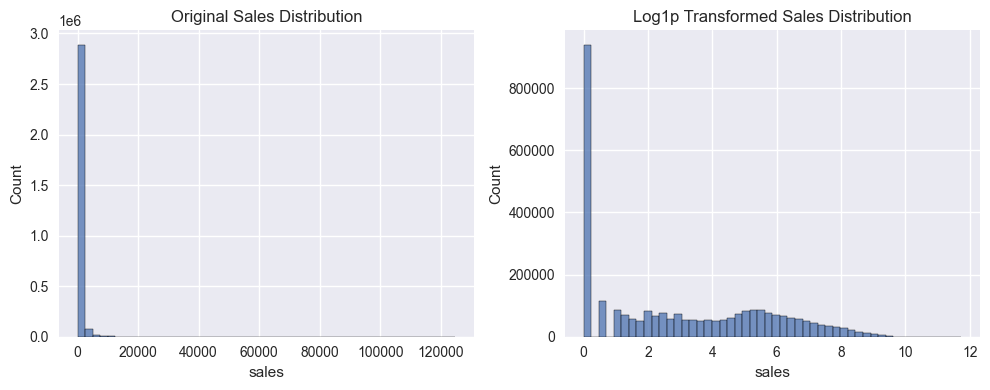

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8')

# 讀取資料
# 確保 date 欄位被讀取為時間格式
df_train = pd.read_csv('./data/train.csv', parse_dates=['date'])
df_test = pd.read_csv('./data/test.csv', parse_dates=['date'])

print(f"Training Data Shape: {df_train.shape}")
print(f"Test Data Shape: {df_test.shape}")

#轉換前的分佈
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_train['sales'], bins=50)
plt.title("Original Sales Distribution")

#執行 Log 轉換
df_train['sales'] = np.log1p(df_train['sales'])

#轉換後的分佈
plt.subplot(1, 2, 2)
sns.histplot(df_train['sales'], bins=50)
plt.title("Log1p Transformed Sales Distribution")
plt.tight_layout()
plt.show()

# 顯示轉換後的數據樣貌
display(df_train.head())

In [ ]:
# 讀取油價資料
df_oil = pd.read_csv('./data/oil.csv', parse_dates=['date'])

# 設定日期為索引，方便後續處理
df_oil = df_oil.set_index('date')

# 建立完整日期範圍
start_date = df_train['date'].min()
end_date = df_test['date'].max()

full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

print(f"油價資料處理範圍: {start_date.date()} 到 {end_date.date()}")

# 3. Reindex
# 把缺失的日期補進來
df_oil = df_oil.reindex(full_date_range)

# 索引名稱可能會遺失，重新命名為 'date'
df_oil.index.name = 'date'

# Linear Interpolate
# limit_direction='both' 確保頭尾的缺值也能被處理
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].interpolate(method='linear', limit_direction='both')

# 重置索引
df_oil = df_oil.reset_index()

# 檢查是否有任何 NaN 殘留
print(f"缺漏值數量 (處理後): {df_oil['dcoilwtico'].isna().sum()}")

# 顯示處理後的油價資料
display(df_oil.head(10))

NameError: name 'df_train_mod' is not defined

In [ ]:
# 讀取假日資料
df_holidays = pd.read_csv('./data/holidays_events.csv', parse_dates=['date'])

print(f"原始假日資料筆數: {df_holidays.shape[0]}")

# 過濾

# 移除被轉移走的節日 (transferred == True)
# 這些日子變成了普通工作日，不再是假日
condition_transferred = df_holidays['transferred'] == True

# 移除補班日 (type == 'Work Day')
# 這些日子雖然在表裡，但其實是要上班的
condition_workday = df_holidays['type'] == 'Work Day'

# 保留: 非上述的資料
df_holidays_clean = df_holidays[~condition_transferred & ~condition_workday].copy()

# 只保留日期、類型、地區資訊
# 重新命名 locale_name，方便之後跟 stores.csv 對接
df_holidays_clean = df_holidays_clean[['date', 'type', 'locale', 'locale_name', 'description']]

print(f"清洗後假日資料筆數: {df_holidays_clean.shape[0]}")
print("-" * 30)
print("清洗後範例 (前5筆):")
display(df_holidays_clean.head())

# 檢查是否還有 Work Day 或 transferred == True (理論上要是 0)
check_errors = df_holidays_clean[
    (df_holidays_clean['type'] == 'Work Day') |
    (df_holidays['transferred'] == True)
]
print(check_errors)

原始假日資料筆數: 350
清洗後假日資料筆數: 333
------------------------------
清洗後範例 (前5筆):


,date,type,locale,locale_name,description
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba


Empty DataFrame
Columns: [date, type, locale, locale_name, description]
Index: []


C:\Users\h0848\AppData\Local\Temp\ipykernel_29148\407723848.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  check_errors = df_holidays_clean[


In [ ]:
# 合併訓練集與測試集
# 為了區分新增一個part欄位
df_train['part'] = 'train'
df_test['part'] = 'test'

# concat
df_main = pd.concat([df_train, df_test], ignore_index=True, sort=False)

print(f"合併後總筆數: {df_main.shape}")

# 建立日期特徵
df_main['month'] = df_main['date'].dt.month
df_main['day'] = df_main['date'].dt.day
df_main['dayofweek'] = df_main['date'].dt.dayofweek  # 0=Monday, 6=Sunday

# 建立發薪日特徵
# 每個月的 15 號 OR 每個月的最後一天
df_main['is_payday'] = (df_main['day'] == 15) | (df_main['date'].dt.is_month_end)
# 轉成 boolean
df_main['is_payday'] = df_main['is_payday'].astype(int)

print("日期與發薪日特徵已建立。")

# 4. 建立 Lag 特徵
# 資料排序，確保 Shift 的時候是針對正確的時間順序
# 排序順序：先分店 -> 再商品 -> 最後按日期
df_main = df_main.sort_values(['store_nbr', 'family', 'date'])

# 定義我們要產生的 Lags
lags = [16, 17, 18, 19, 20, 21, 22]

print(f"開始建立 Lag 特徵 {lags} (請稍候)...")

for lag in lags:
    # groupby: 確保只在 "同一家店" 的 "同一種商品" 內做移動
    # shift(lag): 把 sales 資料往下平移 lag 格
    df_main[f'sales_lag_{lag}'] = df_main.groupby(['store_nbr', 'family'])['sales'].shift(lag)

print(f"Lag 特徵建立完成！")

# 顯示 Test Set 的前幾筆，確認 sales_lag_16 是否有數值
print("-" * 30)
print("檢查 Test Set 的 Lag 資料狀況 (sales_lag_16 應該要有值):")
display(df_main[df_main['part'] == 'test'].head()[['date', 'store_nbr', 'family', 'sales_lag_16']])

合併後總筆數: (3029400, 7)
日期與發薪日特徵已建立。
開始建立 Lag 特徵 [16, 17, 18, 19, 20, 21, 22] (請稍候)...
Lag 特徵建立完成！
------------------------------
檢查 Test Set 的 Lag 資料狀況 (sales_lag_16 應該要有值):


,date,store_nbr,family,sales_lag_16
3000888,2017-08-16,1,AUTOMOTIVE,2.197225
3002670,2017-08-17,1,AUTOMOTIVE,1.791759
3004452,2017-08-18,1,AUTOMOTIVE,1.609438
3006234,2017-08-19,1,AUTOMOTIVE,1.386294
3008016,2017-08-20,1,AUTOMOTIVE,2.197225


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 讀取 Stores 資料
df_stores = pd.read_csv('./data/stores.csv')

# 合併 Stores
df_final = pd.merge(df_main, df_stores, on='store_nbr', how='left')

# 3. 合併 Oil
df_final = pd.merge(df_final, df_oil, on='date', how='left')

# 4. 合併 Holidays
df_final = pd.merge(df_final, df_holidays_clean, on='date', how='left')

rename_dict = {
    'type_x': 'store_type',
    'type_y': 'holiday_type'
}
df_final = df_final.rename(columns=rename_dict)

# 判斷假日的適用地區是否符合商店位置
is_national = df_final['locale'] == 'National'
is_regional = (df_final['locale'] == 'Regional') & (df_final['locale_name'] == df_final['state'])
is_local = (df_final['locale'] == 'Local') & (df_final['locale_name'] == df_final['city'])

# 只要符合其中一個，就是有效假日
mask_holiday_match = is_national | is_regional | is_local

# 準備要清除的欄位
cols_to_clear = ['holiday_type', 'locale', 'locale_name', 'description']

condition_to_clear = (~mask_holiday_match) & (df_final['holiday_type'].notna())

df_final.loc[condition_to_clear, cols_to_clear] = np.nan

# 去除重複
df_final = df_final.drop_duplicates(subset=['date', 'store_nbr', 'family'])

print(f"合併前筆數: {df_main.shape[0]}")
print(f"合併後筆數: {df_final.shape[0]}")

# 移除Desc
if 'description' in df_final.columns:
    df_final = df_final.drop(columns=['description'])
    print("已移除 description 欄位。")

# 缺失值填補
df_final['dcoilwtico'] = df_final['dcoilwtico'].fillna(method='bfill')

# 假日相關補值
df_final['holiday_type'] = df_final['holiday_type'].fillna('WorkDay') # 沒放假就是工作日
df_final['locale'] = df_final['locale'].fillna('Normal')             # 沒有特定地區就是 Normal
# 整合進來的：locale_name 也補 'Normal'
df_final['locale_name'] = df_final['locale_name'].fillna('Normal')

# 類別編碼
cols_to_encode = ['family', 'city', 'state', 'store_type', 'holiday_type', 'locale', 'locale_name']

le = LabelEncoder()
for col in cols_to_encode:
    # 轉成字串以防有混合型態
    df_final[col] = df_final[col].astype(str)
    df_final[col] = le.fit_transform(df_final[col])

print("編碼完成。最終資料集準備就緒！")

# 檢查一下是否還有 NaN
print("locale_name 缺值數:", df_final['locale_name'].isna().sum())
display(df_final.head())

合併前筆數: 3029400
合併後筆數: 3029400
已移除 description 欄位。


C:\Users\h0848\AppData\Local\Temp\ipykernel_29148\1141489501.py:56: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final['dcoilwtico'] = df_final['dcoilwtico'].fillna(method='bfill')


編碼完成。最終資料集準備就緒！
locale_name 缺值數: 0


,id,date,store_nbr,family,sales,onpromotion,part,month,day,dayofweek,...,sales_lag_21,sales_lag_22,city,state,store_type,cluster,dcoilwtico,holiday_type,locale,locale_name
0,0,2013-01-01,1,0,0.000000,0,train,1,1,1,...,NaN,NaN,18,12,3,13,93.140000,3,1,4
1,1782,2013-01-02,1,0,1.098612,0,train,1,2,2,...,NaN,NaN,18,12,3,13,93.140000,5,2,16
2,3564,2013-01-03,1,0,1.386294,0,train,1,3,3,...,NaN,NaN,18,12,3,13,92.970000,5,2,16
3,5346,2013-01-04,1,0,1.386294,0,train,1,4,4,...,NaN,NaN,18,12,3,13,93.120000,5,2,16
4,7128,2013-01-05,1,0,1.791759,0,train,1,5,5,...,NaN,NaN,18,12,3,13,93.146667,5,2,16


使用的特徵數量: 22
特徵列表: ['store_nbr', 'family', 'onpromotion', 'month', 'day', 'dayofweek', 'is_payday', 'sales_lag_16', 'sales_lag_17', 'sales_lag_18', 'sales_lag_19', 'sales_lag_20', 'sales_lag_21', 'sales_lag_22', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type', 'locale', 'locale_name']

開始訓練模型 (這可能需要幾分鐘)...
[0]	validation_0-rmse:2.57231	validation_1-rmse:2.49399
[50]	validation_0-rmse:0.63005	validation_1-rmse:0.47341
[100]	validation_0-rmse:0.53129	validation_1-rmse:0.42162
[150]	validation_0-rmse:0.49125	validation_1-rmse:0.41792
[200]	validation_0-rmse:0.46852	validation_1-rmse:0.41586
[250]	validation_0-rmse:0.45110	validation_1-rmse:0.41551
[294]	validation_0-rmse:0.44061	validation_1-rmse:0.41646

驗證集 RMSLE 分數: 0.41500


<Figure size 1200x1000 with 0 Axes>

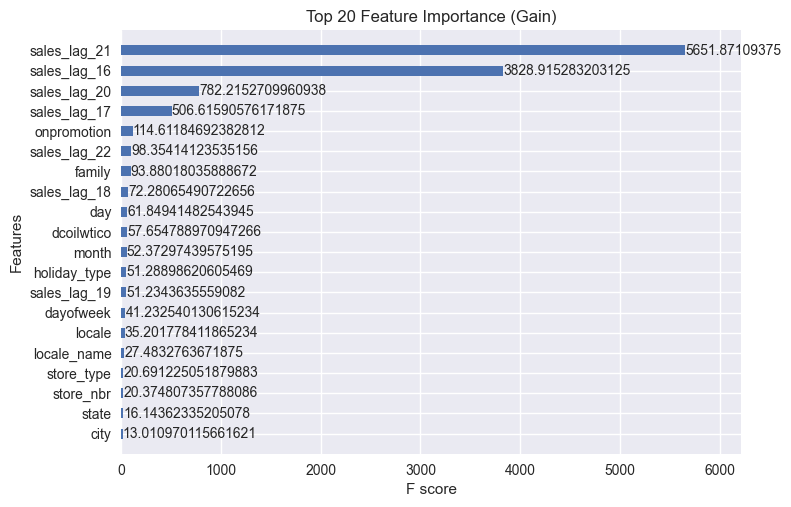

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# 準備資料
# 依據 'part' 欄位分開
mask_train_all = df_final['part'] == 'train'
mask_test_real = df_final['part'] == 'test'

# 取出原本的 Train Set
df_train_full = df_final[mask_train_all].copy()
df_test_pred = df_final[mask_test_real].copy()

# 時間序列切分
# 設定驗證集的截止日 (拿最後 15 天來當驗證集)
val_start_date = '2017-08-01'
val_end_date = '2017-08-15'

mask_val = (df_train_full['date'] >= val_start_date) & (df_train_full['date'] <= val_end_date)
mask_train = df_train_full['date'] < val_start_date

# 排除非特徵欄位
cols_to_drop = ['date', 'sales', 'part', 'id']
features = [c for c in df_train_full.columns if c not in cols_to_drop]

print(f"使用的特徵數量: {len(features)}")
print(f"特徵列表: {features}")

X_train = df_train_full.loc[mask_train, features]
y_train = df_train_full.loc[mask_train, 'sales']

X_val = df_train_full.loc[mask_val, features]
y_val = df_train_full.loc[mask_val, 'sales']

X_test = df_test_pred[features]

# 建立模型
model = xgb.XGBRegressor(
    n_estimators=1000,      # 最多跑 1000 棵樹
    learning_rate=0.05,     # 學習率
    max_depth=10,           # 樹的深度
    subsample=0.8,          # 每次只用 80% 的資料
    colsample_bytree=0.8,   # 每次只用 80% 的特徵
    n_jobs=-1,              
    random_state=42,
    early_stopping_rounds=50 # 50輪沒進步就停
)

print("\n開始訓練模型 (這可能需要幾分鐘)...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

# 評估模型
# 預測驗證集
preds_val = model.predict(X_val)
# 負值修正
preds_val = np.maximum(preds_val, 0)
# 計算 RMSE (因為已經取過 Log，這裡的 RMSE 就等於 RMSLE)
score = np.sqrt(mean_squared_error(y_val, preds_val))
print(f"\n驗證集 RMSLE 分數: {score:.5f}")

plt.figure(figsize=(12, 10))
# importance_type='gain' 最能代表特徵的貢獻度
xgb.plot_importance(model, max_num_features=20, importance_type='gain', height=0.5, title='Top 20 Feature Importance (Gain)')
plt.show()

In [ ]:
importances = model.feature_importances_

# 取得特徵名稱
feature_names = X_train.columns

# 整理成 DataFrame 並排序
feature_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# 依重要性由高到低排序，並取出前 20 名
top_20_df = feature_imp_df.sort_values('importance', ascending=False).head(20)

print("XGBoost 認證的 Top 20 特徵：")
print(top_20_df)

# 產生篩選後的欄位列表
top_20_features = top_20_df['feature'].tolist()
essential_cols = ['id', 'date', 'sales', 'part']

# 組合最終欄位
final_cols = essential_cols + top_20_features
df_selected = df_final[final_cols].copy()

print("-" * 30)
print(f"篩選完成！原本有 {df_final.shape[1]} 個欄位 -> 現在剩下 {df_selected.shape[1]} 個欄位")
display(df_selected.head())

XGBoost 認證的 Top 20 特徵：
         feature  importance
12  sales_lag_21    0.486348
7   sales_lag_16    0.329481
11  sales_lag_20    0.067310
8   sales_lag_17    0.043595
2    onpromotion    0.009862
13  sales_lag_22    0.008463
1         family    0.008078
9   sales_lag_18    0.006220
4            day    0.005322
18    dcoilwtico    0.004961
3          month    0.004507
19  holiday_type    0.004413
10  sales_lag_19    0.004409
5      dayofweek    0.003548
20        locale    0.003029
21   locale_name    0.002365
16    store_type    0.001780
0      store_nbr    0.001753
15         state    0.001389
14          city    0.001120
------------------------------
篩選完成！原本有 26 個欄位 -> 現在剩下 24 個欄位


,id,date,sales,part,sales_lag_21,sales_lag_16,sales_lag_20,sales_lag_17,onpromotion,sales_lag_22,...,month,holiday_type,sales_lag_19,dayofweek,locale,locale_name,store_type,store_nbr,state,city
0,0,2013-01-01,0.000000,train,NaN,NaN,NaN,NaN,0,NaN,...,1,3,NaN,1,1,4,3,1,12,18
1,1782,2013-01-02,1.098612,train,NaN,NaN,NaN,NaN,0,NaN,...,1,5,NaN,2,2,16,3,1,12,18
2,3564,2013-01-03,1.386294,train,NaN,NaN,NaN,NaN,0,NaN,...,1,5,NaN,3,2,16,3,1,12,18
3,5346,2013-01-04,1.386294,train,NaN,NaN,NaN,NaN,0,NaN,...,1,5,NaN,4,2,16,3,1,12,18
4,7128,2013-01-05,1.791759,train,NaN,NaN,NaN,NaN,0,NaN,...,1,5,NaN,5,2,16,3,1,12,18


In [ ]:
import pandas as pd

# 取得 XGBoost 的 Top 20 特徵
importances = model.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
top_20_df = feature_imp_df.sort_values('importance', ascending=False).head(20)

print("XGBoost 原始 Top 20 特徵:")
print(top_20_df['feature'].tolist())

# 轉換為 LSTM 用的特徵列表
# 去除lag
lstm_features = set() # 用 set 避免重複

for feat in top_20_df['feature']:
    if 'lag' in feat:
        # 如果 Lag 入榜，代表 "sales" 本身很重要
        continue
    else:
        lstm_features.add(feat)

lstm_features.add('sales')
lstm_features.add('store_nbr')
lstm_features.add('family')

# 轉回 list 並排序
lstm_features = list(lstm_features)

print("-" * 30)
print(f"經過清洗，LSTM 實際要用的 Base Features ({len(lstm_features)}個):")
print(lstm_features)

# 篩選資料
# 只保留這些 Base Features + id, date, part
cols_to_keep = ['id', 'date', 'part'] + lstm_features
df_selected = df_final[cols_to_keep].copy()
display(df_selected.head())

NameError: name 'model' is not defined